In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import FixedPointInterpolatedUnivariateSpline_SPF, EMP_PSF
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, FixedPointInterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

2026-03-01 15:21:18.444464: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("../docs/tutorials/tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

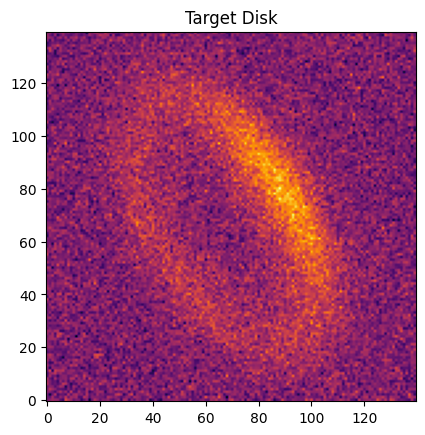

In [3]:
"""inc = 60
spec = "inc{}_spf0_betapos".format(inc)
name = "tutorials/inject_disk_{}.fits".format(spec)
target_img = jnp.array(fits.getdata(name))
plt.imshow(target_img,origin='lower')
H, W = target_img.shape
noise_patch = target_img[:20, W-20:W]
noise_level = jnp.std(noise_patch)
err_map = jnp.ones_like(target_img) * noise_level 

EMP_PSF.img = emp_psf_image"""

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
spf_params = DoubleHenyeyGreenstein_SPF.params
psf_params = EMP_PSF.params

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30
disk_params['beta'] = -1

# Initializing the misc parameter dictionary
misc_params = Parameter_Index.misc_params

# Setting flux_scaling to custom value
misc_params['flux_scaling'] = 1e4
spf_params['num_knots'] = 5

simple_disk_img = objective_model(disk_params, spf_params, psf_params, misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

noise_level = 1
noise = np.random.normal(0, noise_level, simple_disk_img.shape)
target_image = simple_disk_img + noise
err_map = jnp.ones(simple_disk_img.shape)*noise_level
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title('Target Disk')

"""# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.5
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['inclination'] = inc+np.random.normal(6,2)
print(start_disk_params['inclination'])
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5"""
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = FixedPointInterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['forwardscatt_bound'] = 0.9
start_spf_params['knot_values'] = jnp.ones(start_spf_params['num_knots']-1)*1

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 35
start_disk_params['inclination'] = 45
start_disk_params['position_angle'] = 32

misc_params = Parameter_Index.misc_params


In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, FixedPointInterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)

#opt.name = spec

In [5]:
#opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
#opt.initialize_knots(target_image) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

In [6]:
opt.misc_params['flux_scaling'] = 1e3
init_image = opt.get_model()

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 35, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': -1, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 45, 'position_angle': 32, 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': -0.9, 'forwardscatt_bound': 0.9, 'num_knots': 5, 'knot_values': Array([1., 1., 1., 1.], dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 1000.0}


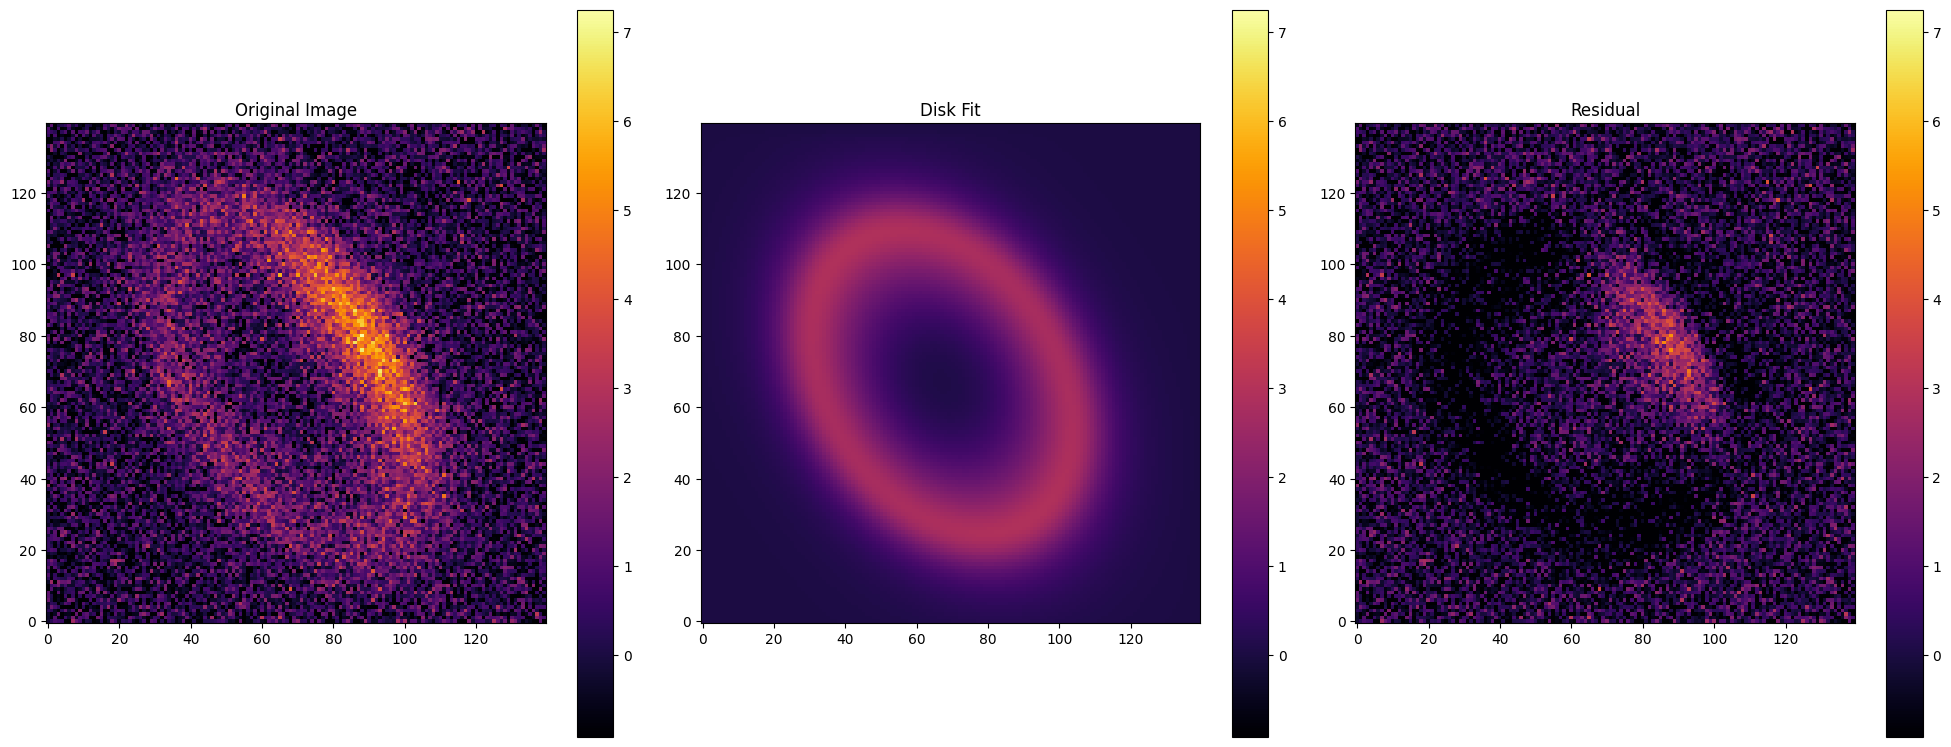

In [7]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image, 10)
vmax = np.nanpercentile(target_image, 100)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(init_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-init_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
#plt.savefig('{}_scipyminimize_img.png'.format(name))

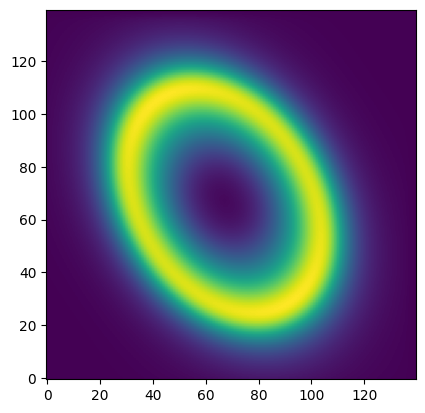

In [8]:
plt.imshow(opt.get_model(),origin='lower')

In [ ]:
fit_keys = ['sma', 'inclination', 'position_angle', 'beta', 'knot_values', 'flux_scaling']
logscaled_params = ['knot_values', 'flux_scaling']
array_params = ['knot_values']
bounds = ([0, 0, 0,-5, np.zeros(opt.spf_params["num_knots"]-1), 0],
          [150, 180, 400, 5, 1e4*np.ones(opt.spf_params["num_knots"]-1), 1e14])

#soln = opt.scipy_optimize(fit_keys,  logscaled_params, array_params, target_image, err_map, use_grad=False,method='Nelder-Mead',maxiter=500)
soln = opt.torch_optimize(fit_keys, logscaled_params, array_params, target_image, err_map, optimizer_type='SGD')
optimal_image = opt.get_model()

Optimizing NLL via PyTorch Adam...


In [10]:
#soln.x
soln

[34.090134,
 49.3424,
 30.690956,
 -0.86975086,
 array([2.8567445, 0.758218 , 0.3777852, 1.3754777], dtype=float32),
 149.57404]

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 34.090134, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': -0.86975086, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 49.3424, 'position_angle': 30.690956, 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': -0.9, 'forwardscatt_bound': 0.9, 'num_knots': 5, 'knot_values': array([2.8567445, 0.758218 , 0.3777852, 1.3754777], dtype=float32)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 149.57404}


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

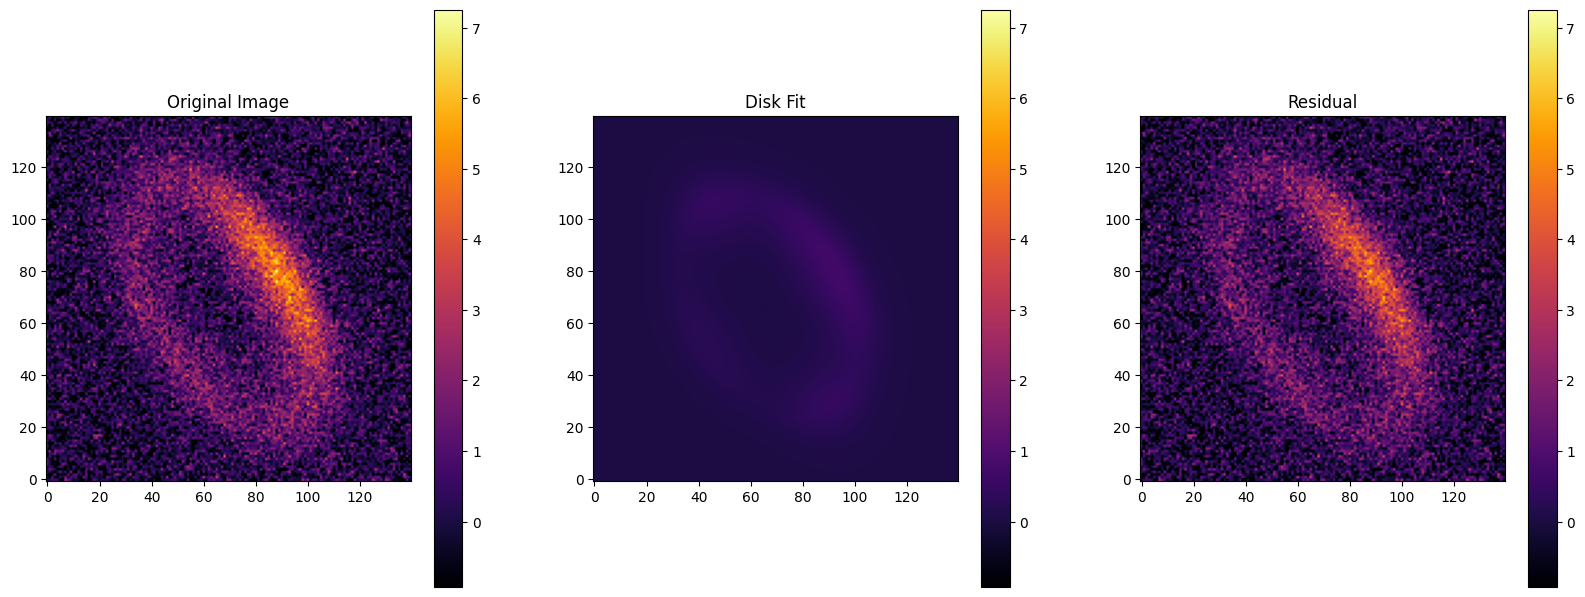

In [11]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image, 10)
vmax = np.nanpercentile(target_image, 100)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout
#plt.savefig('{}_scipyminimize_img.png'.format(name))

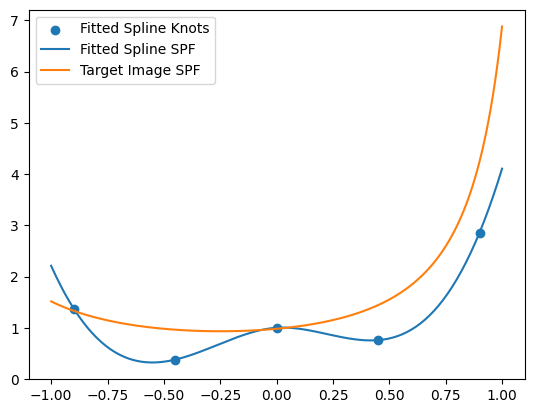

In [12]:
x_vals = jnp.linspace(-1, 1, 200)
knot_locs = FixedPointInterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)
plt.scatter(knot_locs, FixedPointInterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, FixedPointInterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.plot(x_vals, DoubleHenyeyGreenstein_SPF.compute_phase_function_from_cosphi(DoubleHenyeyGreenstein_SPF.pack_pars(spf_params), x_vals)/0.05)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])

In [13]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

fit_keys = ['sma', 'inclination', 'position_angle', 'beta', 'knot_values', 'flux_scaling']
bounds = ([0, 0, 0,-5, np.zeros(opt.spf_params["num_knots"]-1), 0],
          [150, 180, 400, 5, 1e4*np.ones(opt.spf_params["num_knots"]-1), 1e14])
mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=500, burns=100)

Running burn-in...


100%|██████████| 100/100 [00:49<00:00,  2.02it/s]


Running production...


100%|██████████| 500/500 [02:33<00:00,  3.26it/s]


Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 34.26713987851586, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': -0.29209338695617815, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 48.74302030499749, 'position_angle': 31.13772748568585, 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': -0.9, 'forwardscatt_bound': 0.9, 'num_knots': 5, 'knot_values': array([4.06433834, 0.71505102, 0.61742077, 3.10249008])}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 113.88401413056486}


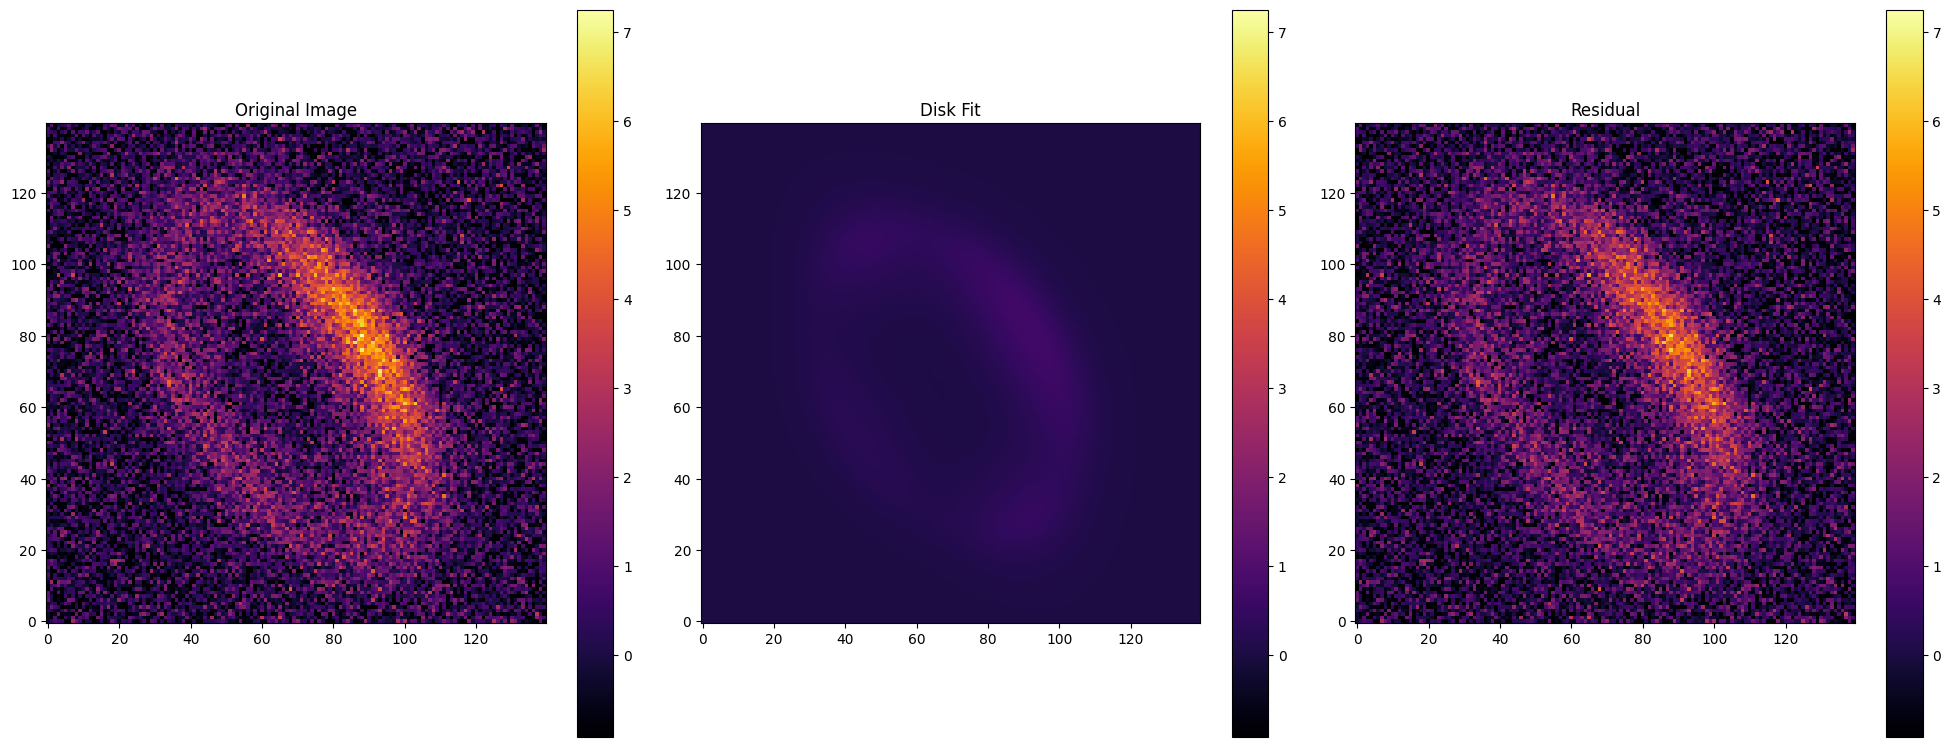

In [14]:
mc_model.set_discarded_iters(200)
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image, 10)
vmax = np.nanpercentile(target_image, 100)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
#plt.savefig('{}_mcmc_img.png'.format(name))

In [15]:
print(np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params))))

[ 25.84193276  63.25631605  90.         116.74368395 154.15806724]


In [16]:
print(opt.spf_params)

{'backscatt_bound': -0.9, 'forwardscatt_bound': 0.9, 'num_knots': 5, 'knot_values': array([4.06433834, 0.71505102, 0.61742077, 3.10249008])}


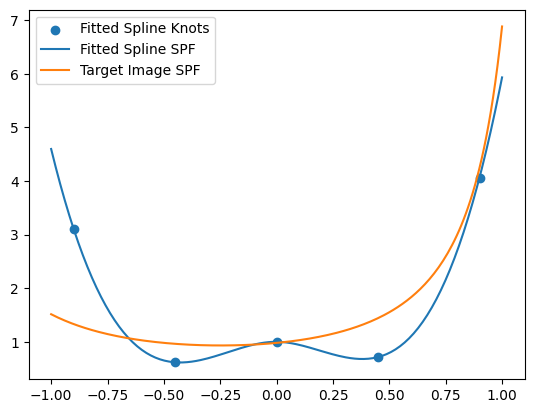

In [17]:
x_vals = jnp.linspace(-1, 1, 200)
knot_locs = FixedPointInterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)
plt.scatter(knot_locs, FixedPointInterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, FixedPointInterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.plot(x_vals, DoubleHenyeyGreenstein_SPF.compute_phase_function_from_cosphi(DoubleHenyeyGreenstein_SPF.pack_pars(spf_params), x_vals)/0.05)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])

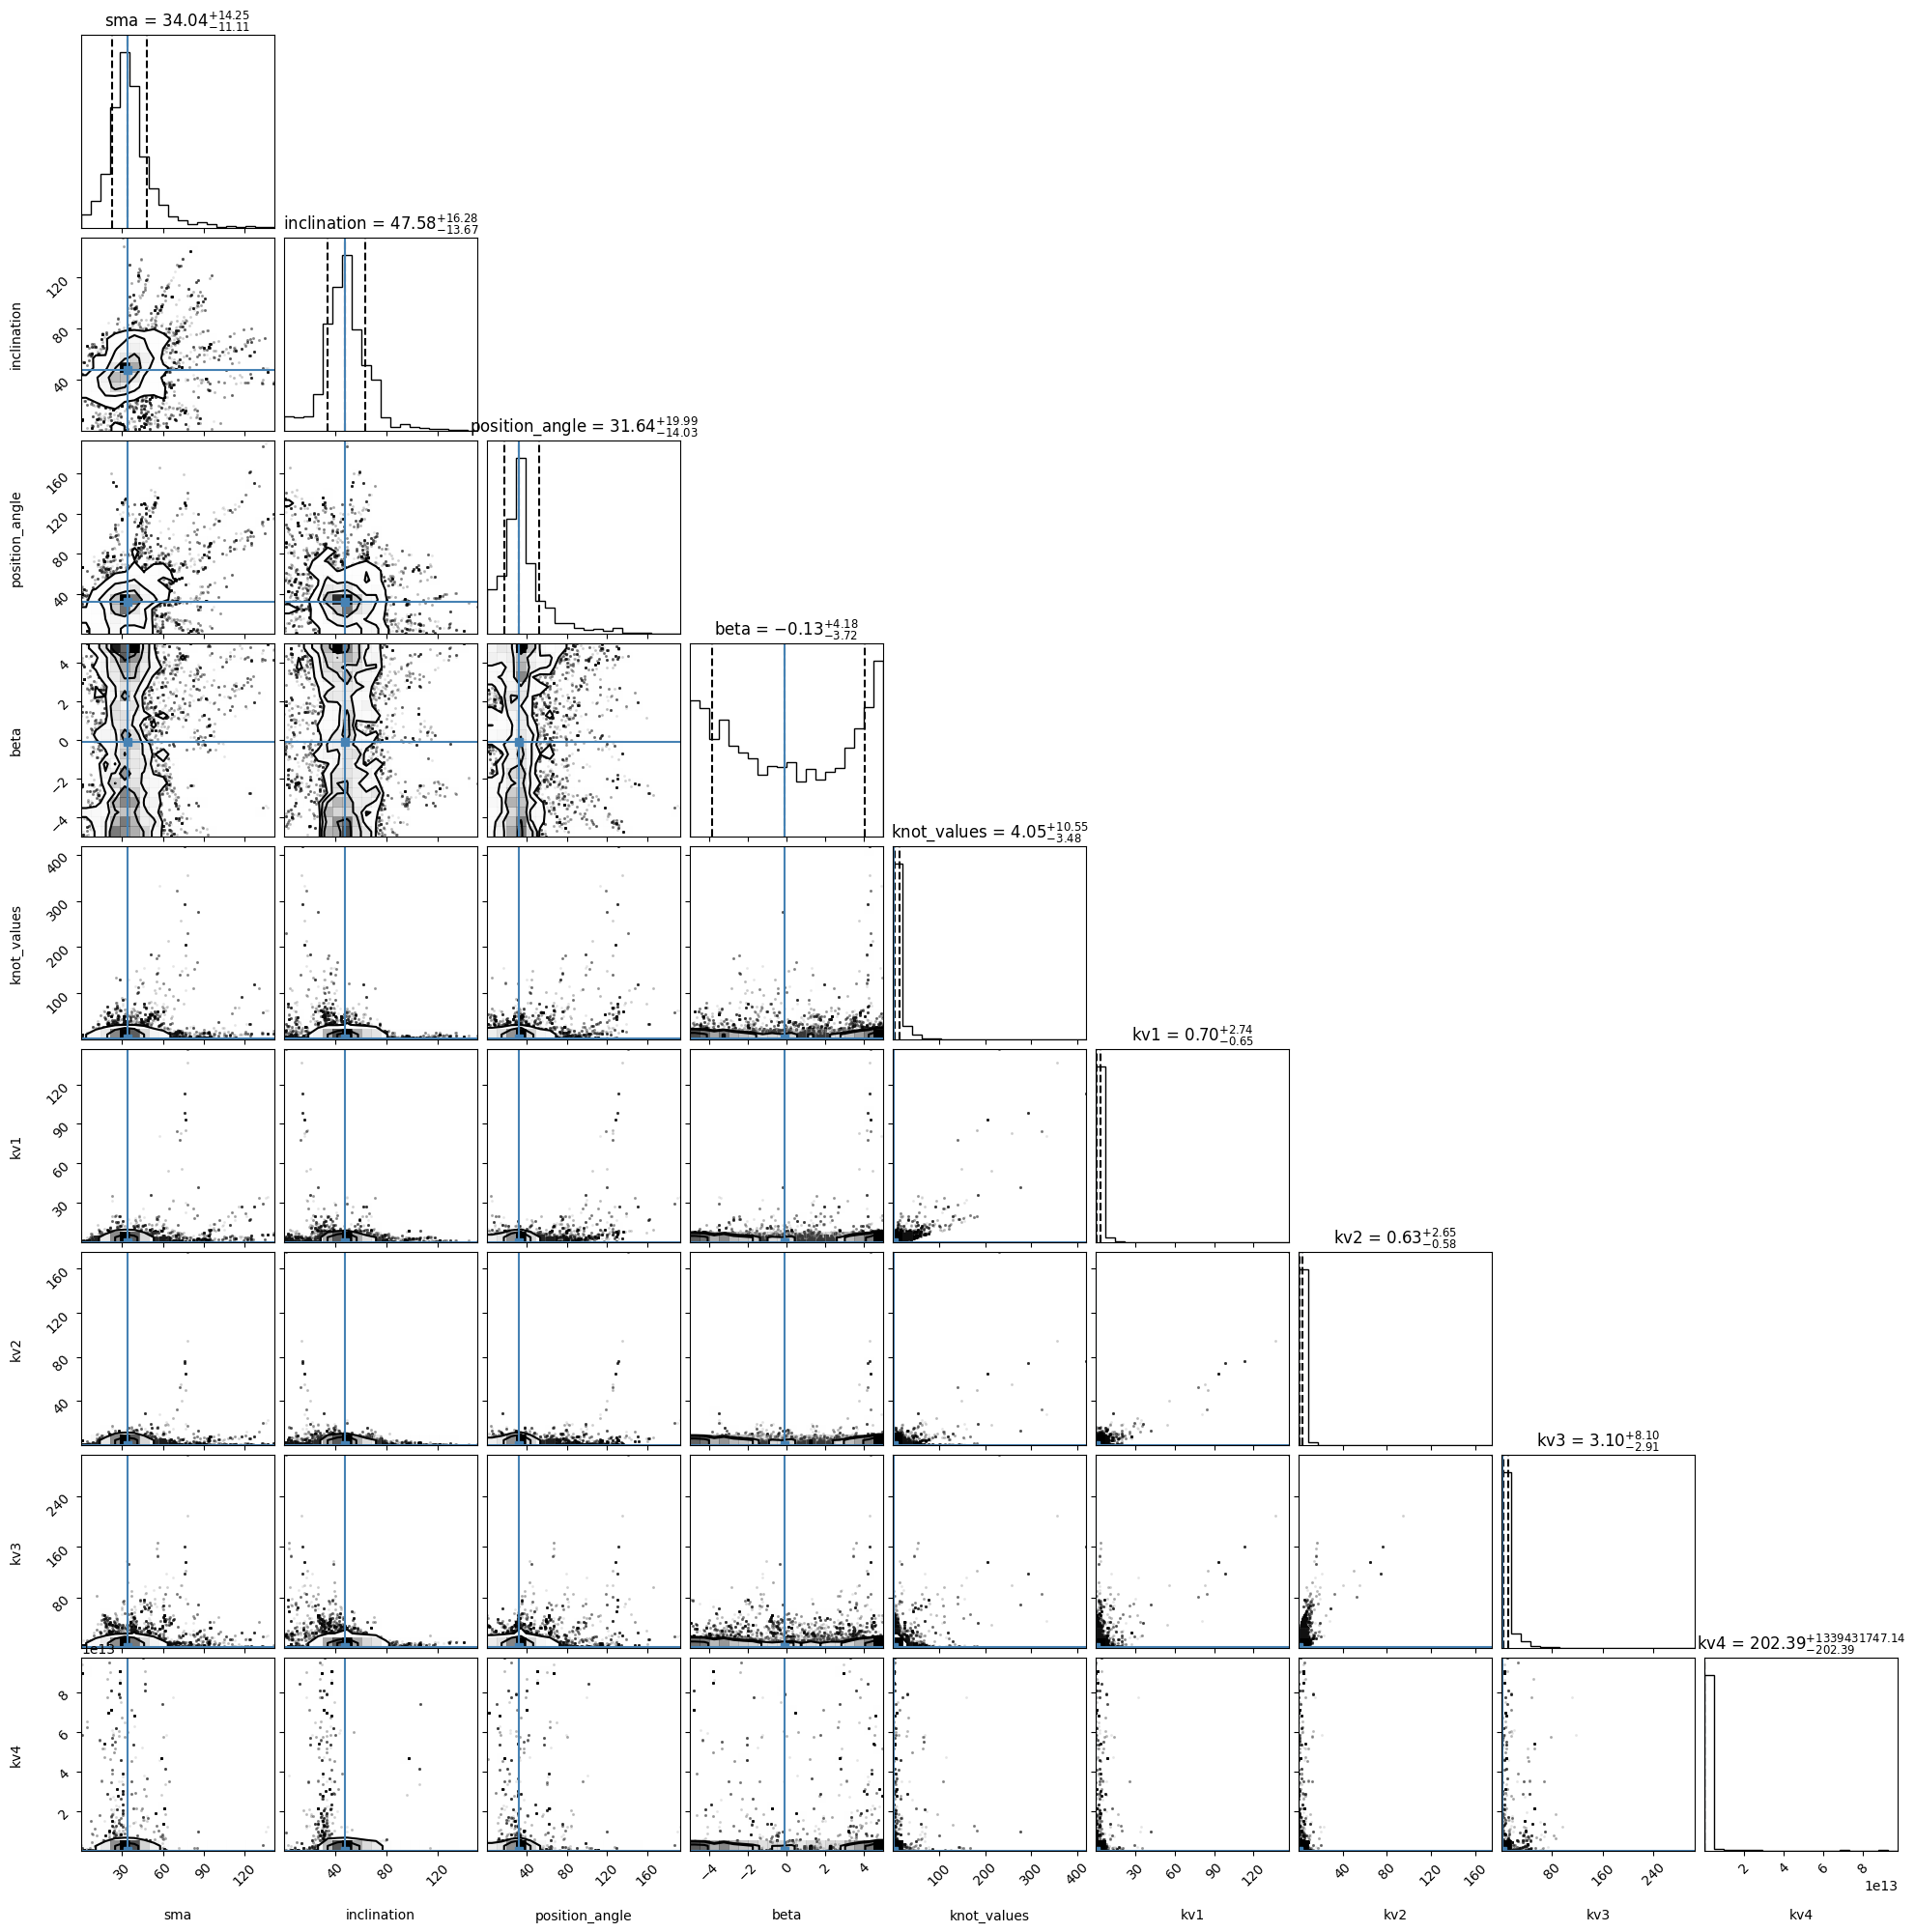

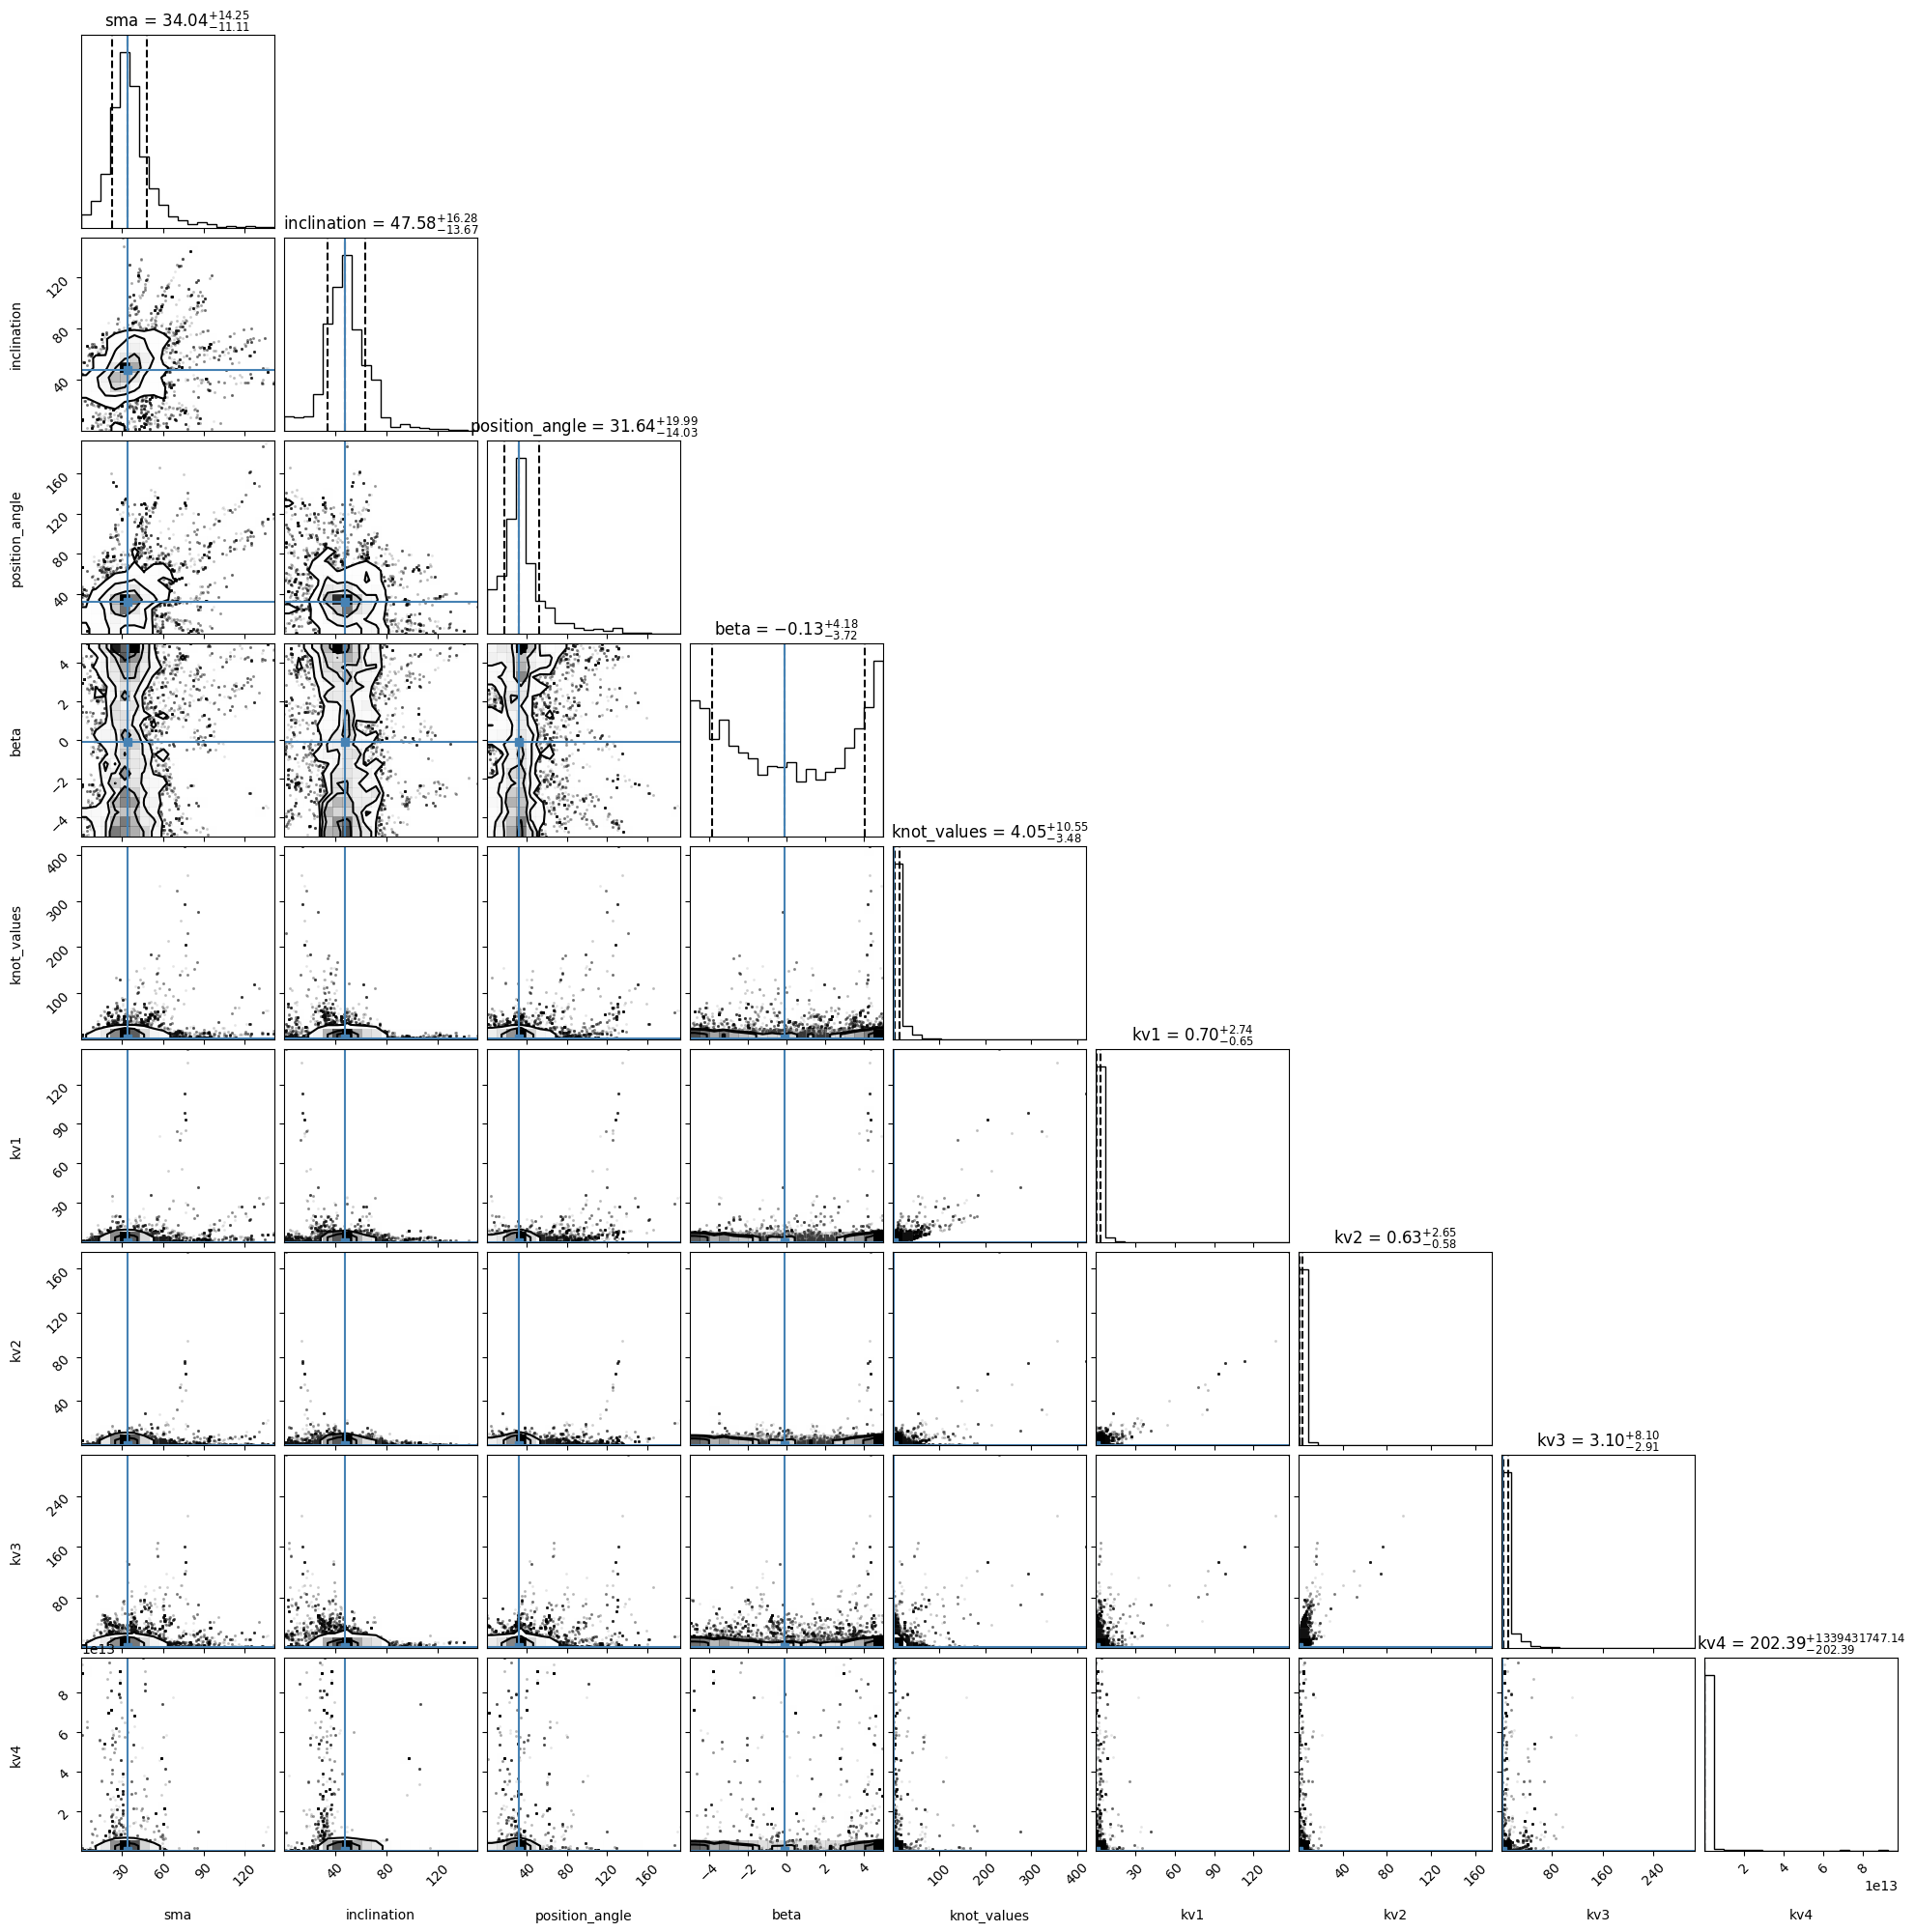

In [21]:
mc_soln = mc_model.get_theta_median()
mc_model.show_corner_plot(fit_keys[:-1]+['kv1','kv2','kv3','kv4']+[fit_keys[-1]], truths=mc_soln, scaled=True)

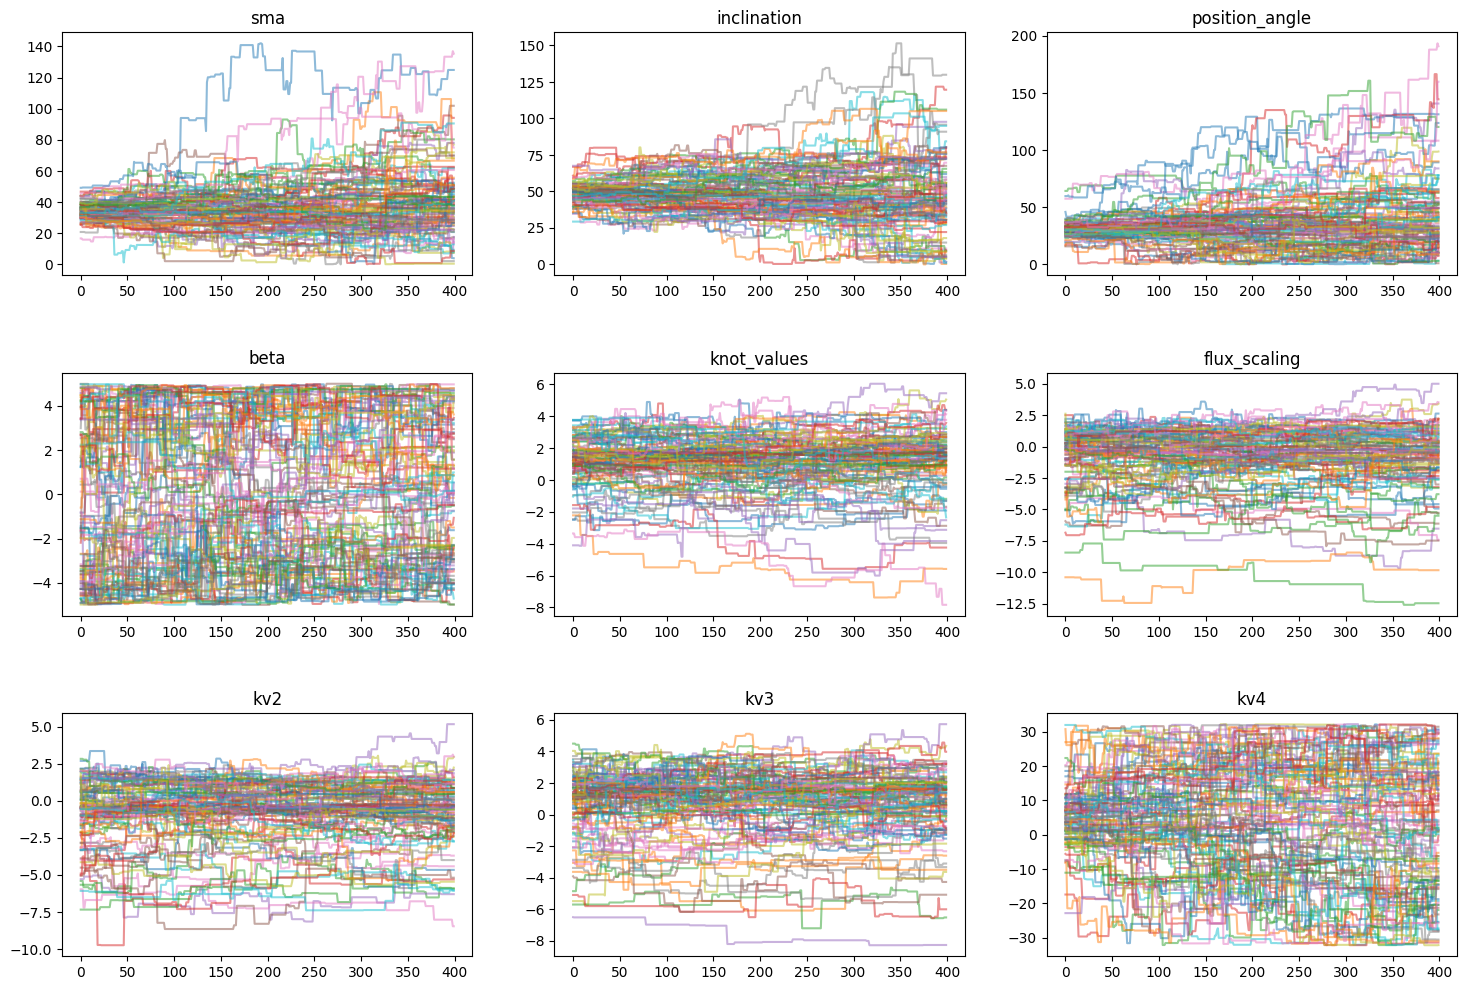

In [19]:
mc_model.plot_chains(fit_keys+['kv2','kv3','kv4','kv5'])

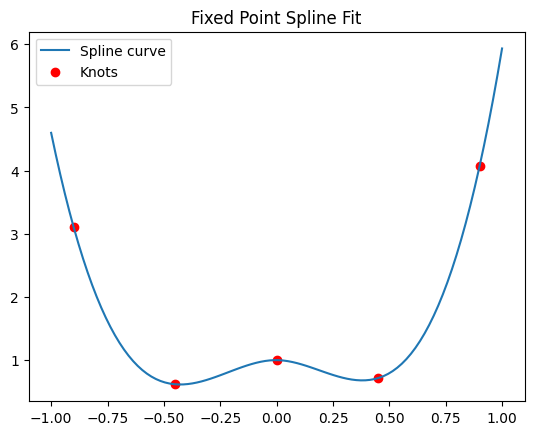

In [20]:
opt.plot_spline()
print()